In [1]:
import pickle
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from typing import List, Tuple

import main
import forward_models

In [2]:
CONTROL_TIMESTEP_DAYS = 3
INITIAL_SOIL_MOISTURE = 0.125
INITIAL_AMMONIUM_GN_PER_M3 = 0.105
INITIAL_NITRATE_GN_PER_M3 = 0.3
STARTING_INDICES = main.values_to_indices(INITIAL_SOIL_MOISTURE, INITIAL_AMMONIUM_GN_PER_M3, INITIAL_NITRATE_GN_PER_M3)
RAINY_START = 1
STARTING_INDICES

(2, 0, 0)

In [3]:
# time, forecast, moisture, starting ammonium, starting nitrate, 
#     -> does leaching limit get violated, n accumulation, end moisture, end ammonium, end nitrate
with open(str(CONTROL_TIMESTEP_DAYS) + "_transition_counts.pickle", 'rb') as f:
    transition_counts = pickle.load(f) 
with open(str(CONTROL_TIMESTEP_DAYS) + "_expected_plant_N_deficit.pickle", 'rb') as f:
    expected_plant_N_deficit_cost_USD = pickle.load(f)
with open(str(CONTROL_TIMESTEP_DAYS) + "_controllers.pkl", 'rb') as f:
    controllers = pickle.load(f)

In [4]:
selected_penalty = list(controllers.keys())[1]
selected_penalty

np.float64(0.20126710688876742)

In [5]:
controller = controllers[selected_penalty]

In [6]:
starting_ammonium_idx = STARTING_INDICES[1] + controller[1][0, 0, 0, RAINY_START, *STARTING_INDICES]
starting_nitrate_idx = STARTING_INDICES[2] + controller[2][0, 0, 0, RAINY_START, *STARTING_INDICES]
[starting_ammonium_gN_per_m3, starting_nitrate_gN_per_m3] = main.n_indices_to_values(starting_ammonium_idx, starting_nitrate_idx)
if starting_ammonium_idx == STARTING_INDICES[1]:
    starting_ammonium_gN_per_m3 = INITIAL_AMMONIUM_GN_PER_M3
if starting_nitrate_idx == STARTING_INDICES[2]:
    starting_nitrate_gN_per_m3 = INITIAL_NITRATE_GN_PER_M3
[starting_ammonium_gN_per_m3, starting_nitrate_gN_per_m3]

[0.105, np.float64(78.37320281787991)]

In [9]:
# tuple is: end_of_day_soil_moistures, infiltration_rate_mm_per_day, evaporation_rate_mm_per_day, transpiration_rate_mm_per_day, leakage_rate_mm_per_day, moisture_effect_on_decomposition_factor, moisture_effect_on_nitrification_factor
def soil_states_from_hydrology(hydrology: Tuple[npt.NDArray[np.float64],npt.NDArray[np.float64],npt.NDArray[np.float64],npt.NDArray[np.float64],npt.NDArray[np.float64],npt.NDArray[np.float64],npt.NDArray[np.float64]]) -> Tuple[npt.NDArray[np.float64], npt.NDArray[np.float64], npt.NDArray[np.bool]]:
    num_days = len(hydrology[0])
    _, _, eod_biomass_carbon_g_per_m3, _, net_flux_to_mineralized_nitrogen_g_per_m3_per_day = forward_models.soil_organic_model(main.INITIAL_LITTER_CARBON_GC_PER_M3, main.INITIAL_LITTER_NITROGEN_GN_PER_M3, main.INITIAL_MICROBIAL_CARBON_GC_PER_M3, main.INITIAL_HUMUS_CARBON_GC_PER_M3, hydrology[5], np.zeros(num_days), np.zeros(num_days))
    sod_soil_moistures = np.insert(hydrology[0], 0, INITIAL_SOIL_MOISTURE)
    sod_biomass_carbon_gC_per_m3 = np.insert(eod_biomass_carbon_g_per_m3, 0, main.INITIAL_MICROBIAL_CARBON_GC_PER_M3)
    eop_ammonium_nitrogen_g_per_m3, eop_nitrate_nitrogen_g_per_m3, ammonium_leaching_gN_per_m3_per_day, nitrate_leaching_gN_per_m3_per_day, plant_passive_uptake_of_ammonium_gN_per_m3_per_day, plant_passive_uptake_of_nitrate_gN_per_m3_per_day, plant_active_uptake_of_ammonium_gN_per_m3_per_day, plant_active_uptake_of_nitrate_gN_per_m3_per_day, assumptions_violation, _  = forward_models.inorganic_nitrogen_model(starting_ammonium_gN_per_m3, starting_nitrate_gN_per_m3, 0, hydrology[4], hydrology[3], sod_soil_moistures, net_flux_to_mineralized_nitrogen_g_per_m3_per_day, sod_biomass_carbon_gC_per_m3, main.day_to_plant_N_demand_gN_per_m3_per_day, output_dt_days=main.INORGANIC_N_MODEL_DT_DAYS)
    leaching_limit_violated_yet = np.zeros(num_days, dtype=np.bool)
    for i in range(0, num_days, main.LEACHING_AVERAGE_WINDOW_DAYS):
        total_leakage_L_per_m3 = np.sum(hydrology[4][i:(i+main.LEACHING_AVERAGE_WINDOW_DAYS)])
        inorganic_n_model_lower_limit = int(i / main.INORGANIC_N_MODEL_DT_DAYS)
        inorganic_n_model_upper_limit = int((i + main.LEACHING_AVERAGE_WINDOW_DAYS) / main.INORGANIC_N_MODEL_DT_DAYS)
        if total_leakage_L_per_m3 > 0 and (np.sum(ammonium_leaching_gN_per_m3_per_day[inorganic_n_model_lower_limit:inorganic_n_model_upper_limit]) + np.sum(nitrate_leaching_gN_per_m3_per_day[inorganic_n_model_lower_limit:inorganic_n_model_upper_limit])) * main.INORGANIC_N_MODEL_DT_DAYS / total_leakage_L_per_m3 > (main.LEACHING_CONCENTRATION_LIMIT_MG_PER_LITER / 1000.):
            leaching_limit_violated_yet[i:] = 1
            break
    return hydrology[0], eop_ammonium_nitrogen_g_per_m3, eop_nitrate_nitrogen_g_per_m3, leaching_limit_violated_yet

In [10]:
# with open("rollout_rainfalls.pkl", 'rb') as f:
    # rollout_rainfalls = pickle.load(f)
rollout_rainfalls = []
for i in range(10000):
    rollout_rainfalls.append(forward_models.generate_rain(main.NUM_DAYS_TOTAL))
rollout_rainfalls_filtered_start = filter(lambda x: np.array_equal(x[0:3], [0.0, 0.0, 0.0]) == (RAINY_START == 0), rollout_rainfalls)
rollout_hydrologies_filtered_start = map(lambda x: forward_models.hydrology_model(INITIAL_SOIL_MOISTURE, x), rollout_rainfalls_filtered_start)
rollout_soil_states_filtered_start = list(map(soil_states_from_hydrology, rollout_hydrologies_filtered_start))
len(rollout_soil_states_filtered_start)

5949

In [24]:
def eod_index_percents_from_rollout_soil_states(day: int, rollout_soil_states: List[Tuple[npt.NDArray[np.float64], npt.NDArray[np.float64], npt.NDArray[np.bool]]]):
    n_day_index = int((day + 1) / main.INORGANIC_N_MODEL_DT_DAYS) - 1
    soil_state_indices = list(map(lambda x: main.values_to_indices(x[0][day], x[1][n_day_index], x[2][n_day_index]), rollout_soil_states))
    num_steps = [main.MOISTURE_NUM_STEPS, main.AMMONIUM_NUM_STEPS, main.NITRATE_NUM_STEPS]
    index_percents = []
    for i in range(3):
        uniq = np.unique_counts(list(map(lambda x: x[i], soil_state_indices)))
        # print(uniq)
        counts_dict = dict(zip(uniq.values, uniq.counts))
        out = np.zeros(num_steps[i])
        for j in range(num_steps[i]):
            out[j] = counts_dict.get(j, 0)
        index_percents.append(out / np.sum(out))
    return index_percents

In [25]:
leakage_index = main.values_to_indices(forward_models.FIELD_CAPACITY, 0, 0)[0]
leakage_index

6

Step 1 (day 3) violation %: kernel=0.110, rollout=0.123
	probability of being in leakage: kernel=0.195, rollout=0.220
Step 2 (day 6) violation %: kernel=0.251, rollout=0.273
	probability of being in leakage: kernel=0.257, rollout=0.279
Step 3 (day 9) violation %: kernel=0.347, rollout=0.376
	probability of being in leakage: kernel=0.295, rollout=0.319
Step 4 (day 12) violation %: kernel=0.425, rollout=0.456
	probability of being in leakage: kernel=0.324, rollout=0.349
Step 5 (day 15) violation %: kernel=0.491, rollout=0.523
	probability of being in leakage: kernel=0.344, rollout=0.371
Step 6 (day 18) violation %: kernel=0.538, rollout=0.569
	probability of being in leakage: kernel=0.360, rollout=0.384
Step 7 (day 21) violation %: kernel=0.566, rollout=0.580
	probability of being in leakage: kernel=0.371, rollout=0.384
Step 8 (day 24) violation %: kernel=0.584, rollout=0.583
	probability of being in leakage: kernel=0.380, rollout=0.396
Step 9 (day 27) violation %: kernel=0.598, rollout=

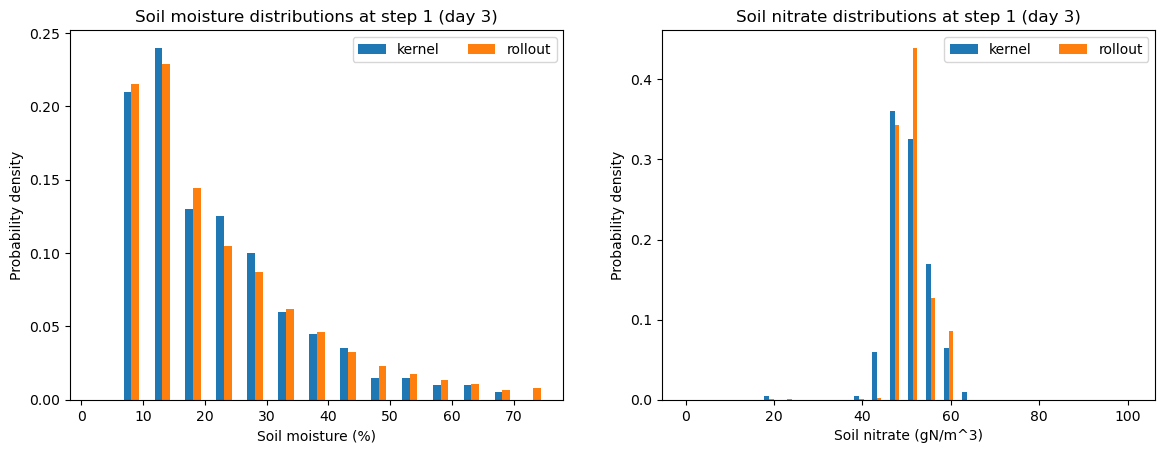

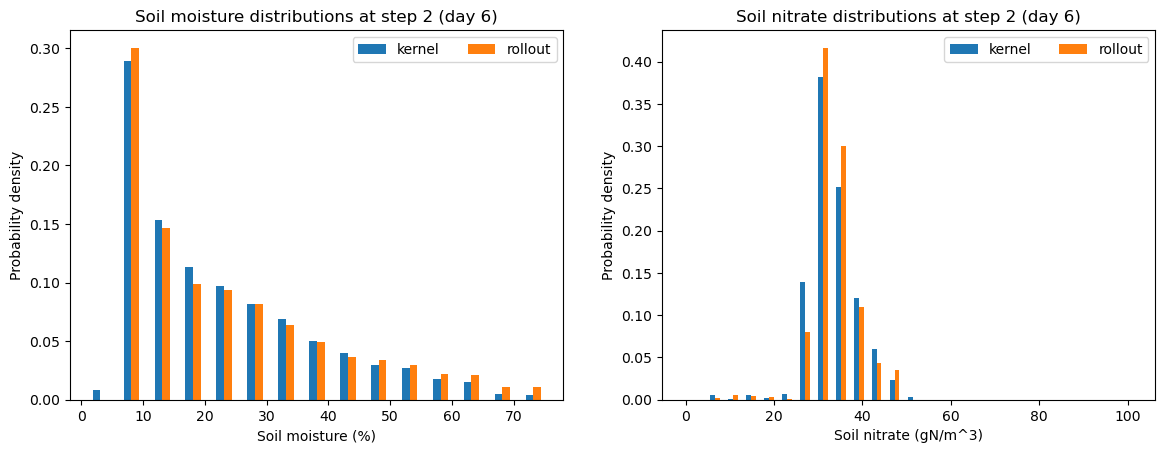

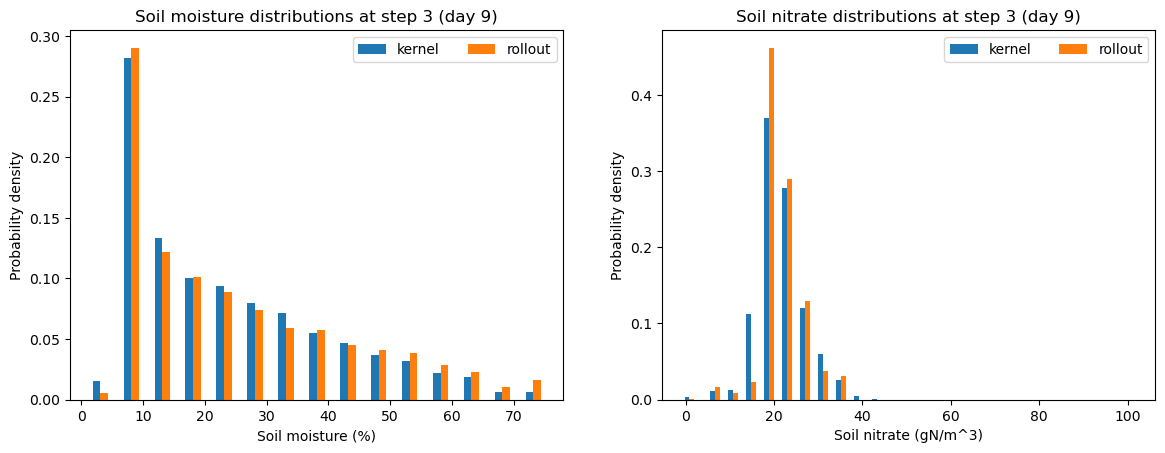

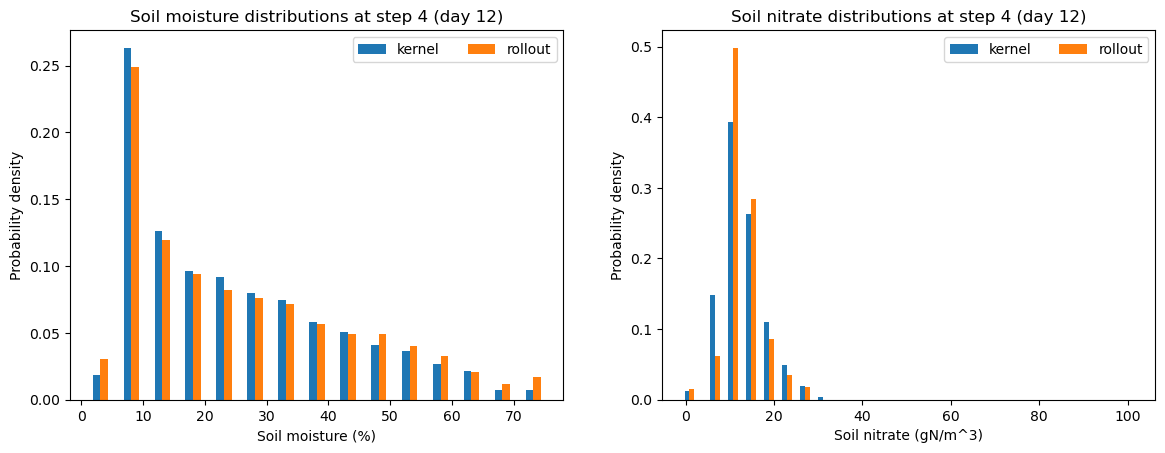

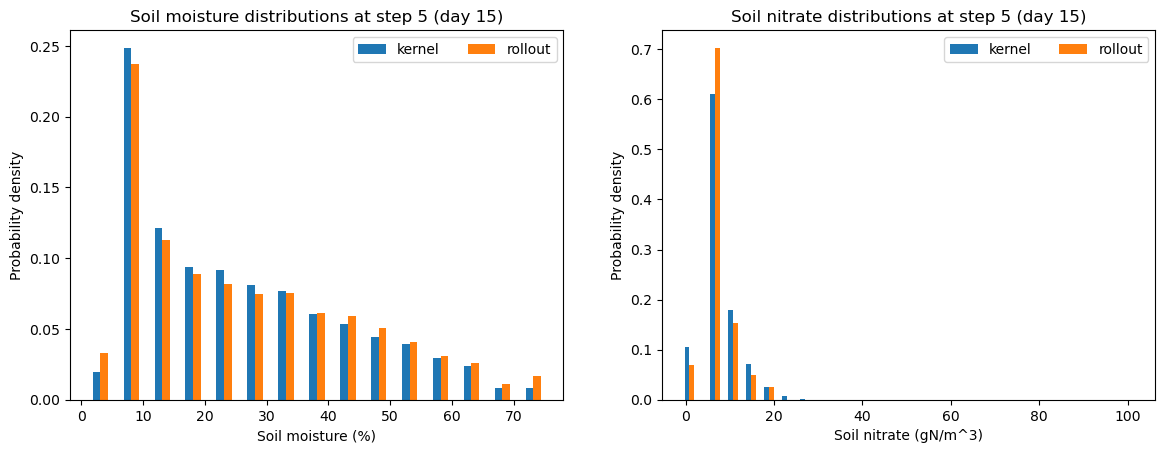

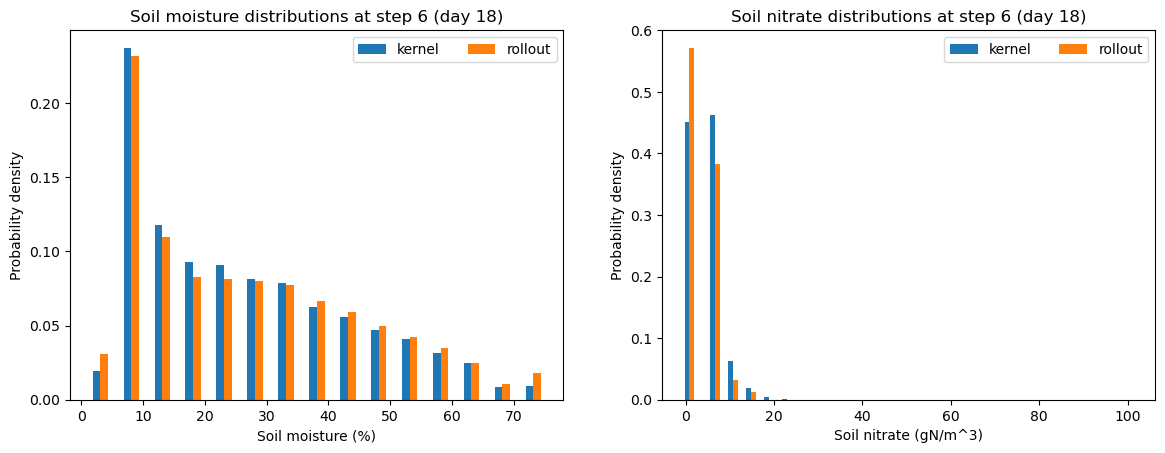

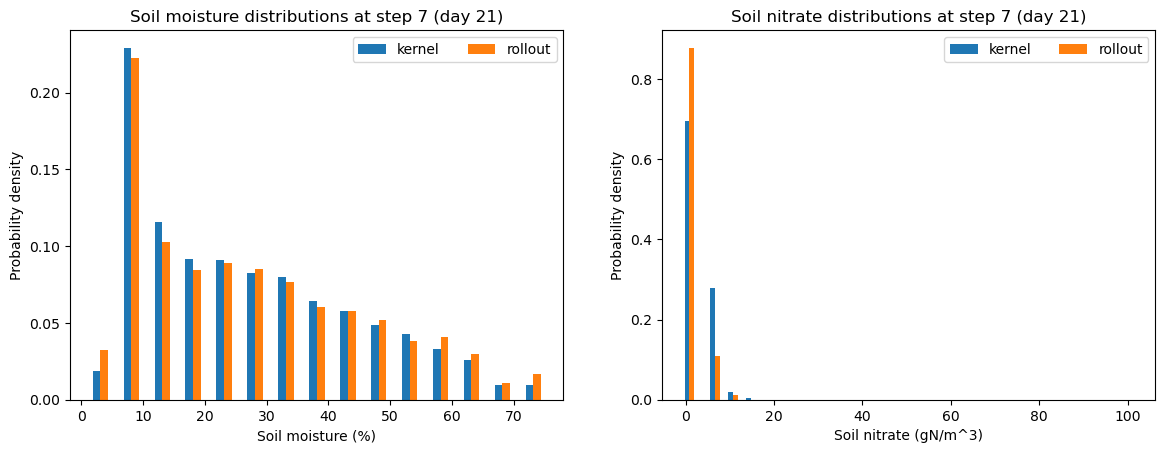

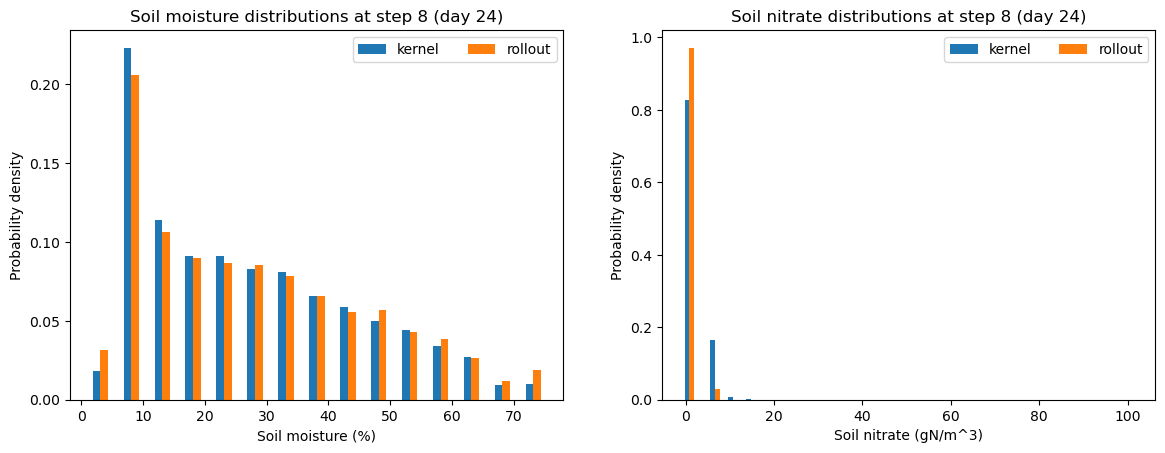

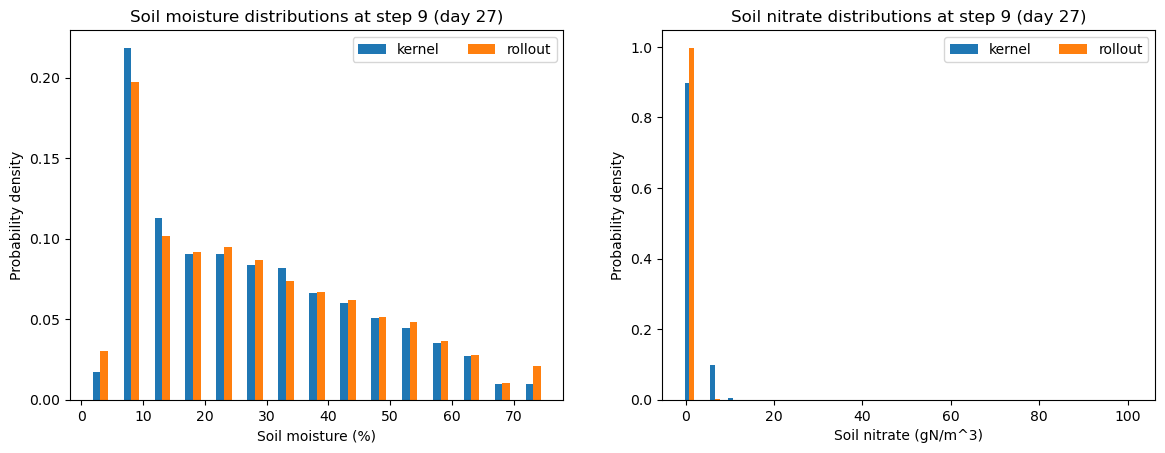

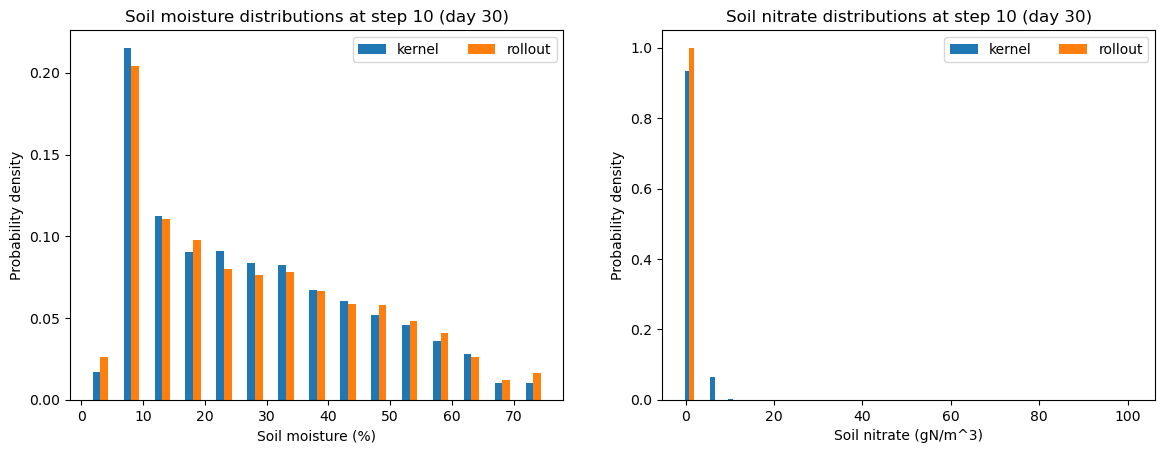

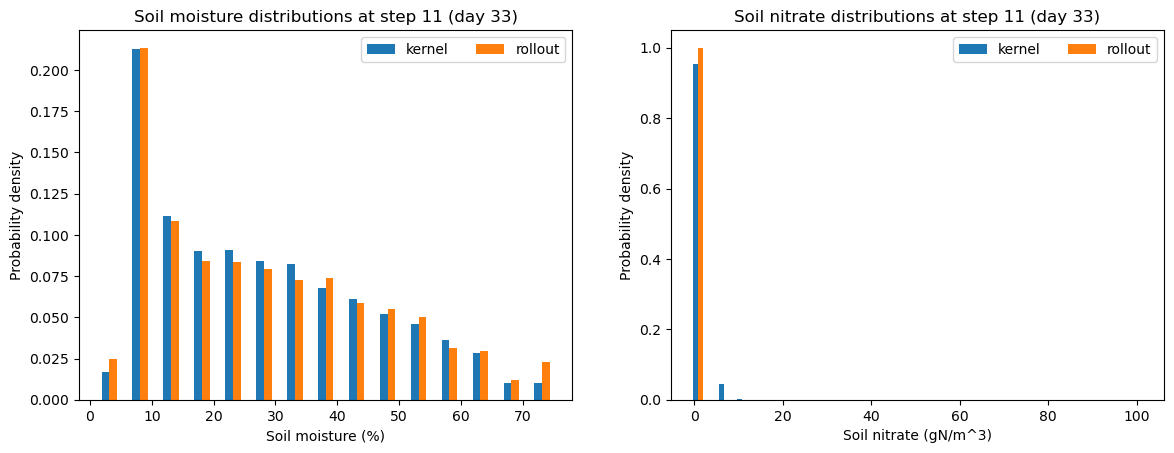

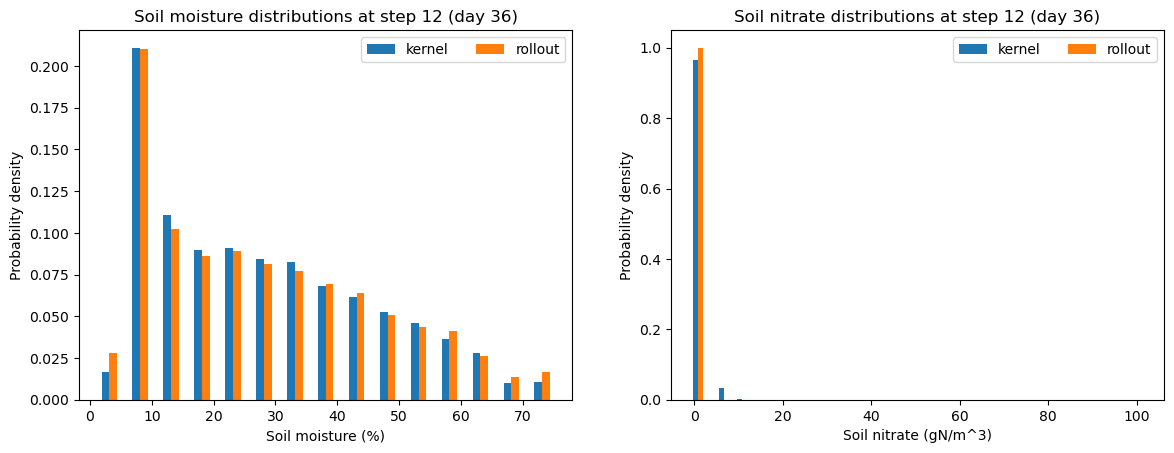

In [28]:
soil_states = transition_counts[0, RAINY_START, STARTING_INDICES[0], starting_ammonium_idx, starting_nitrate_idx].sum(axis=(1), dtype=np.float64)
soil_states = soil_states / soil_states.sum()
soil_states_shape = soil_states.shape
for i in range(1,transition_counts.shape[0] + 1):
    # print(np.sum(soil_states))
    moisture_percents_by_idx = soil_states.sum(axis=(0,2,3)) / soil_states.sum()
    nitrate_percents_by_idx = soil_states.sum(axis=(0,1,2)) / soil_states.sum()
    day = CONTROL_TIMESTEP_DAYS * i
    rollout_soil_state_index_percents = eod_index_percents_from_rollout_soil_states(day - 1, rollout_soil_states_filtered_start)
    
    fig, axs = plt.subplots(1,2, figsize=[7*2, 4.8])
    
    moisture_x = np.linspace(main.MOISTURE_GRID_SIZE / 2, main.MAX_MOISTURE - (main.MOISTURE_GRID_SIZE / 2), main.MOISTURE_NUM_STEPS) * 100
    moisture_width = 25 * main.MOISTURE_GRID_SIZE  # the width of the bars
    axs[0].bar(moisture_x, moisture_percents_by_idx, moisture_width, label="kernel")
    axs[0].bar(moisture_x + moisture_width, rollout_soil_state_index_percents[0], moisture_width, label="rollout")
    axs[0].set_ylabel("Probability density")
    axs[0].set_xlabel("Soil moisture (%)")
    axs[0].legend(loc='upper right', ncols=2)
    axs[0].set_title("Soil moisture distributions at step {} (day {})".format(i, day))

    nitrate_x = np.linspace(main.NITRATE_GRID_SIZE / 2, main.MAX_NITRATE - (main.NITRATE_GRID_SIZE / 2), main.NITRATE_NUM_STEPS)
    nitrate_x[0] = main.leaching_safe_N_threshold_gN_per_m3 / 4
    nitrate_width = 0.25 * main.NITRATE_GRID_SIZE  # the width of the bars
    axs[1].bar(nitrate_x, nitrate_percents_by_idx, nitrate_width, label="kernel")
    axs[1].bar(nitrate_x + nitrate_width, rollout_soil_state_index_percents[2], nitrate_width, label="rollout")
    axs[1].set_ylabel("Probability density")
    axs[1].set_xlabel("Soil nitrate (gN/m^3)")
    axs[1].legend(loc='upper right', ncols=2)
    axs[1].set_title("Soil nitrate distributions at step {} (day {})".format(i, day))

    kernel_violation_percent = soil_states[1].sum() / soil_states.sum()
    rollout_violation_percent = sum(map(lambda x: x[3][day - 1], rollout_soil_states_filtered_start)) / len(rollout_soil_states_filtered_start)
    print("Step {} (day {}) violation %: kernel={:.3f}, rollout={:.3f}".format(i, day, kernel_violation_percent, rollout_violation_percent))
    print("\tprobability of being in leakage: kernel={:.3f}, rollout={:.3f}".format(np.sum(moisture_percents_by_idx[leakage_index:]), np.sum(rollout_soil_state_index_percents[0][leakage_index:])))

    if (i < transition_counts.shape[0]):
        base_mapping_matrix = 2 * transition_counts[i, 0].sum(axis=4) + 3 * transition_counts[i, 1].sum(axis=4)
        block_size = int(soil_states.size / 2)
        mapping_matrix = np.block([
            [base_mapping_matrix[:, :, :, 0].reshape(block_size, block_size).transpose(), np.zeros((block_size, block_size))],
            [base_mapping_matrix[:, :, :, 1].reshape(block_size, block_size).transpose(), base_mapping_matrix.sum(axis=3).reshape(block_size, block_size).transpose()]
        ])
        next_soil_states_flat = np.matmul(mapping_matrix, soil_states.reshape(-1))
        soil_states = next_soil_states_flat.reshape(soil_states_shape) / main.NUM_TRIALS_PER_INITIAL_CONDITION / 5.0
    

In [20]:
soil_states = transition_counts[0, RAINY_START, STARTING_INDICES[0], starting_ammonium_idx, starting_nitrate_idx].sum(axis=(1), dtype=np.float64)
print(np.sum(soil_states))
print(soil_states.size)
soil_states

200.0
7500


array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
    

In [13]:
base_mapping_matrix = 2 * transition_counts[i, 0].sum(axis=4) + 3 * transition_counts[i, 1].sum(axis=4)
mapping_matrix = np.block([
    [base_mapping_matrix[:, :, :, 0].reshape(4000, 4000).transpose(), np.zeros((4000, 4000))],
    [base_mapping_matrix[:, :, :, 1].reshape(4000, 4000).transpose(), base_mapping_matrix.sum(axis=3).reshape(4000,4000).transpose()]
])

In [15]:
soil_states.reshape(-1)

array([0., 0., 0., ..., 0., 0., 0.], shape=(7500,))

In [14]:
new_states = np.matmul(mapping_matrix, soil_states.reshape(-1))
np.sum(new_states)

np.float64(72000.0)

In [15]:
sum(map(lambda x: x[3][9], rollout_soil_states_filtered_start))

np.int64(2736)

In [16]:
np.unique_counts(mapping_matrix.sum(axis=0))

UniqueCountsResult(values=array([600.]), counts=array([8000]))

In [17]:
120 * 5

600

In [18]:
bottom_right = base_mapping_matrix.sum(axis=3).reshape(4000, 4000)

In [19]:
np.unique_counts(bottom_right.transpose().sum(axis=0))

UniqueCountsResult(values=array([600], dtype=uint64), counts=array([4000]))

In [20]:
2 * transition_counts[i, 0].sum(axis=4) + 3 * transition_counts[i, 1].sum(axis=4)

array([[[[[[[351,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            ...,
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0]],

           [[ 90,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            ...,
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0]],

           [[ 63,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            ...,
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0],
            [  0,   0,   0, ...,   0,   0,   0]],

           ...,

           [[  0,   0,   0, ...,   0,   0,  

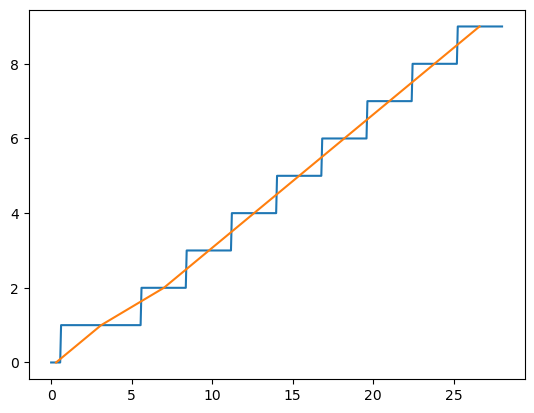

In [21]:
x = np.linspace(0, main.MAX_AMMONIUM, 500)
val_to_idx = np.vectorize(lambda x: main.values_to_indices(0, x, 0)[1])
y = val_to_idx(x)
idx_to_val = np.vectorize(lambda x: main.indices_to_values(0, 0, x, 0)[2])
plt.plot(x, y)
plt.plot(idx_to_val(y), y)

In [22]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6,

In [23]:
main.AMMONIUM_GRID_SIZE * 2

5.6000000000000005

In [27]:
rainfalls = {"early_rain": [], "no_early_rain": []}
for forecast in ["early_rain", "no_early_rain"]:
    i = 0
    while i < 1000:
        candidate_rain = forward_models.generate_rain(4)
        if (any(candidate_rain[:main.FORECAST_LOOKAHEAD_DAYS] > 0) and forecast == "early_rain") or (
                (not any(candidate_rain[:main.FORECAST_LOOKAHEAD_DAYS] > 0)) and forecast == "no_early_rain"):
            rainfalls[forecast].append(candidate_rain)
            i += 1

SOM_and_hydrology_per_moisture = []
for moisture_idx_for_hydrology in range(main.MOISTURE_NUM_STEPS):
    trial_results = {"early_rain": [], "no_early_rain": []}
    for forecast in ["early_rain", "no_early_rain"]:
        for rainfall in rainfalls[forecast]:
            initial_moisture_for_hydrology = main.sample_from_indices(moisture_idx_for_hydrology, 0, 0)[0]
            result = main.simulate_from_rain_through_SOM(rainfall, initial_moisture_for_hydrology)
            trial_results[forecast].append(result)
    SOM_and_hydrology_per_moisture.append(trial_results)

In [28]:
SOM_and_hydrology_per_moisture[2]["early_rain"][0][2]

array([0.11845474, 0.09616581, 0.08082409, 0.12110395])

In [29]:
# initial_day_idx, initial_forecast_idx, initial_moisture_idx, initial_ammonium_idx, initial_nitrate_idx
transition_probs = main.transition_probabilities_from_initial_condition(SOM_and_hydrology_per_moisture, (0, 1, 2, 0, 0), end_states_dtype=np.int64)[5]

In [30]:
transition_probs.sum(axis=(0, 1, 3, 4))/transition_probs.sum()

array([0.   , 0.203, 0.222, 0.138, 0.134, 0.083, 0.064, 0.044, 0.03 ,
       0.025, 0.022, 0.007, 0.011, 0.008, 0.002, 0.007])

Text(0.5, 1.0, 'Soil moisture distributions at step 1 (day 3)')

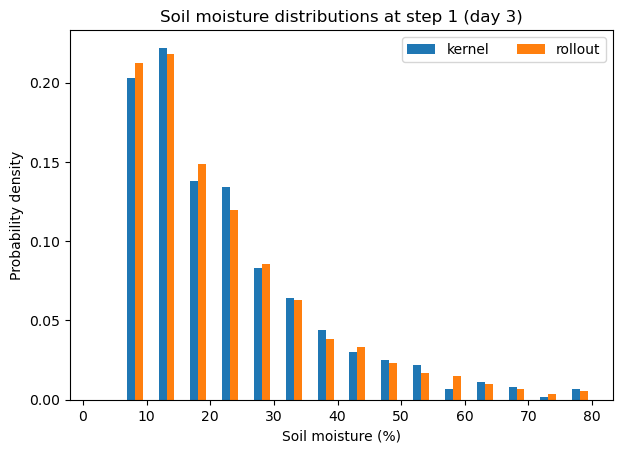

In [31]:
day = CONTROL_TIMESTEP_DAYS * 1
rollout_soil_state_index_percents = index_percents_from_rollout_soil_states(day, rollout_soil_states_filtered_start)

fig, axs = plt.subplots(1,1, figsize=[7, 4.8])

moisture_x = np.linspace(main.MOISTURE_GRID_SIZE / 2, main.MAX_MOISTURE - (main.MOISTURE_GRID_SIZE / 2), main.MOISTURE_NUM_STEPS) * 100
moisture_width = 25 * main.MOISTURE_GRID_SIZE  # the width of the bars
axs.bar(moisture_x, transition_probs.sum(axis=(0, 1, 3, 4))/transition_probs.sum(), moisture_width, label="kernel")
axs.bar(moisture_x + moisture_width, rollout_soil_state_index_percents[0], moisture_width, label="rollout")
axs.set_ylabel("Probability density")
axs.set_xlabel("Soil moisture (%)")
axs.legend(loc='upper right', ncols=2)
axs.set_title("Soil moisture distributions at step 1 (day {})".format(day))

In [32]:
transition_probs.sum()

np.int64(1000)

In [33]:
transition_probs.max()

np.int64(222)

In [34]:
transition_probs.min()

np.int64(0)